# 01 - EDA Overview Y Calidad De Datos

## Hipotesis iniciales

1. Las fuentes procesadas deben estar limpias y listas para ser usadas como base reproducible del proyecto, sin depender de `data/raw`.
2. Las tablas tienen granularidades distintas: cliente, cliente-mes, zona-mes, evento de soporte y encuesta. Por tanto, el principal riesgo tecnico es unirlas sin respetar claves temporales.
3. La calidad del dato no solo debe verse como un problema de limpieza: los flags de imputacion, correccion o valores invalidos pueden convertirse en senales predictivas.
4. La cobertura temporal debe ser suficientemente consistente entre fuentes para construir variables disponibles en el mes `t` y predecir churn en `t+1`.
5. Si quedan nulos residuales, duplicados o inconsistencias de claves, el EDA posterior y el modelado pueden quedar sesgados.

## Que se va a contrastar

- Volumen, columnas, nulos y cobertura temporal de cada fuente procesada.
- Consistencia entre clientes, target, facturacion y soporte.
- Acciones de limpieza aplicadas y posibles senales derivadas para feature engineering.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

files = {
    'clientes': 'clientes_clean.csv',
    'churn': 'churn_target_clean.csv',
    'facturacion': 'facturacion_mensual_clean.csv',
    'calidad_senal': 'calidad_senal_zona_mensual_clean.csv',
    'soporte': 'interacciones_soporte_clean.csv',
    'encuestas': 'encuestas_texto_clean.csv',
}

dfs = {name: pd.read_csv(PROCESSED / file) for name, file in files.items()}
for name, df in dfs.items():
    for col in ['fecha', 'mes', 'fecha_evento']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
quality = pd.read_csv(PROCESSED / 'data_quality_report.csv')


In [2]:
summary = []
for name, df in dfs.items():
    keys = [c for c in ['cliente_id', 'zona_id', 'fecha', 'mes', 'fecha_evento'] if c in df.columns]
    summary.append({
        'fuente': name,
        'filas': len(df),
        'columnas': df.shape[1],
        'nulos_totales': int(df.isna().sum().sum()),
        'claves_visibles': ', '.join(keys),
    })
summary_df = pd.DataFrame(summary)
display(summary_df)


,fuente,filas,columnas,nulos_totales,claves_visibles
0,clientes,10000,23,0,"cliente_id, zona_id"
1,churn,321987,3,0,"cliente_id, fecha"
2,facturacion,321987,16,0,"cliente_id, zona_id, fecha"
3,calidad_senal,1080,15,0,"zona_id, fecha"
4,soporte,303929,16,0,"cliente_id, mes, fecha_evento"
5,encuestas,1000,14,0,"zona_id, fecha"


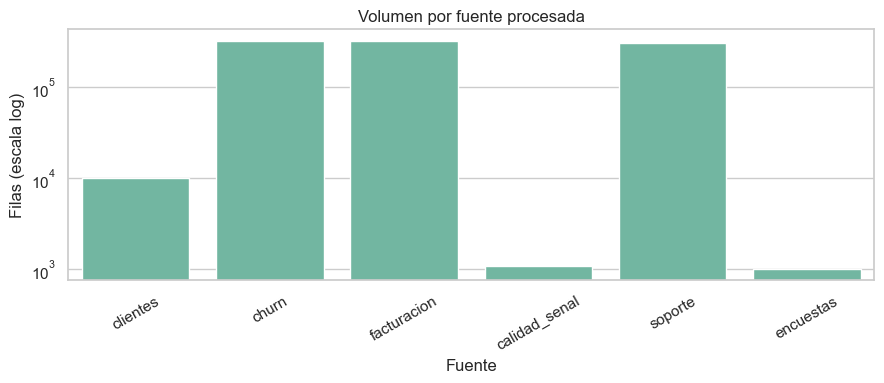

In [3]:
plt.figure(figsize=(9, 4))
sns.barplot(data=summary_df, x='fuente', y='filas')
plt.yscale('log')
plt.title('Volumen por fuente procesada')
plt.xlabel('Fuente')
plt.ylabel('Filas (escala log)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [4]:
coverage = []
for name, df in dfs.items():
    date_col = 'fecha' if 'fecha' in df.columns else 'mes' if 'mes' in df.columns else None
    if date_col:
        coverage.append({
            'fuente': name,
            'fecha_min': df[date_col].min(),
            'fecha_max': df[date_col].max(),
            'meses_unicos': df[date_col].dt.to_period('M').nunique(),
        })
display(pd.DataFrame(coverage))


,fuente,fecha_min,fecha_max,meses_unicos
0,churn,2023-01-01,2025-12-01,36
1,facturacion,2023-01-01,2025-12-01,36
2,calidad_senal,2023-01-01,2025-12-01,36
3,soporte,2023-01-01,2025-12-01,36
4,encuestas,2023-01-01,2025-12-01,36


In [5]:
missing = []
for name, df in dfs.items():
    miss = df.isna().mean().sort_values(ascending=False).head(8)
    for col, pct in miss.items():
        if pct > 0:
            missing.append({'fuente': name, 'columna': col, 'pct_nulos': pct * 100})
missing_df = pd.DataFrame(missing)
if not missing_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=missing_df, y='columna', x='pct_nulos', hue='fuente')
    plt.title('Nulos residuales tras limpieza')
    plt.xlabel('% nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()
else:
    print('No quedan nulos residuales relevantes en las columnas principales revisadas.')


No quedan nulos residuales relevantes en las columnas principales revisadas.


In [6]:
quality_view = quality.groupby(['dataset', 'metric'], as_index=False).agg(
    acciones=('action', 'first'),
    antes=('value_before', 'first'),
    despues=('value_after', 'first')
)
display(quality_view.head(30))


,dataset,metric,acciones,antes,despues
0,calidad_senal_zona_mensual,cobertura_4g_pct_fuera_rango,clip 0-100,0,0
1,calidad_senal_zona_mensual,cobertura_4g_pct_imputados,mediana por tipo_zona,32,0
2,calidad_senal_zona_mensual,cobertura_5g_pct_fuera_rango,clip 0-100,0,0
3,calidad_senal_zona_mensual,cobertura_5g_pct_imputados,mediana por tipo_zona,32,0
4,calidad_senal_zona_mensual,duplicados_exactos,drop_duplicates,16,0
5,calidad_senal_zona_mensual,duplicados_zona_mes,agregacion zona-mes,0,0
6,calidad_senal_zona_mensual,fecha_nulos,normalizar fecha a mes,0,0
7,calidad_senal_zona_mensual,latencia_ms_imputados,mediana por tipo_zona,32,0
8,churn_target,churn_fuera_catalogo,filtrar binario,0,0
9,churn_target,duplicados_cliente_mes,max churn,0,0


In [7]:
clientes = dfs['clientes']
churn = dfs['churn']
fact = dfs['facturacion']
soporte = dfs['soporte']
print('Clientes en clientes_clean:', clientes['cliente_id'].nunique())
print('Clientes en churn_target_clean:', churn['cliente_id'].nunique())
print('Clientes en facturacion_clean:', fact['cliente_id'].nunique())
print('Clientes en soporte_clean:', soporte['cliente_id'].nunique())
print('Clientes con target y sin ficha cliente:', len(set(churn['cliente_id']) - set(clientes['cliente_id'])))


Clientes en clientes_clean: 10000
Clientes en churn_target_clean: 10000
Clientes en facturacion_clean: 10000
Clientes en soporte_clean: 9973
Clientes con target y sin ficha cliente: 0


## Conclusiones finales

- Las fuentes procesadas forman una base comun reproducible: clientes, target de churn, facturacion, calidad de red, soporte y encuestas estan disponibles en `data/processed`.
- El volumen confirma granularidades diferentes: `churn_target_clean` y `facturacion_mensual_clean` trabajan a nivel cliente-mes, `calidad_senal_zona_mensual_clean` a nivel zona-mes, soporte a nivel evento y encuestas a nivel respuesta/zona.
- La cobertura temporal principal llega de 2023-01 a 2025-12 en las fuentes mensuales revisadas, suficiente para construir historicos, lags y validacion temporal.
- No aparecen nulos residuales relevantes en las columnas principales revisadas, por lo que la limpieza es adecuada para continuar con EDA especificos.
- La union final debe hacerse respetando disponibilidad temporal: todas las variables explicativas deben existir hasta el mes `t` y el objetivo debe medir churn posterior.

## Decisiones para feature engineering

- Usar `churn_target_clean` como calendario cliente-mes.
- Agregar soporte a cliente-mes antes de unirlo al target.
- Agregar encuestas y calidad de red a zona-mes.
- Mantener flags de imputacion/correccion como posibles senales predictivas.
- Documentar cualquier transformacion temporal para evitar leakage.
